# Does a long lower wick really mark a floor? 🔨
### The hammer & the hanging man — the candle traders swear marks a turn, on the real tape

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reliable_reversal%3F: Busted](https://img.shields.io/badge/Reliable_reversal%3F-Busted-8b949e?style=flat-square)

Here is one of the most-taught chart patterns on the internet. A candle with a tiny body perched at the **top** of the day's range and a **long tail hanging down** below it. After a slide, they call it a **hammer** — *"the market hammered out a bottom, buy it."* After a rally, the *exact same shape* is a **hanging man** — *"the top is hanging by a thread, sell."* The long lower wick is supposed to mean buyers stepped in and rejected the lows: a floor you can see.

It's a great story. The wick **is** real information about *that day* — price went down and got pushed back up. The question is whether it tells you anything about the **next few days**. We checked, on **60+ years** of daily bars across 26 big US stocks plus the S&P.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Fixed **26-name** survivor basket + SPY (names still trading today). Survivors *recover* from dips that delisted names didn't — so the bias actually leans **toward** finding a bounce. If even *that* shows no floor, the floor really isn't there. Charts are drawn by the code beside them; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hammer_hanging_man import data, strategy as st

ASOF = "2026-06-23"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = {t: b[b.index <= ASOF] for t, b in data.load_real().items()}
else:
    PANEL = None
print("real hammer cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-23', 'start': '1962-01-02', 'end': '2026-06-23', 'n_names': 26, 'n_bars': 345716, 'n_shape': 11816, 'fp': 'd488237f4299', 'hammer': {1: (5152, -0.031, -0.82, 0.869, -0.131), 3: (5149, 0.052, 0.92, 0.128, -0.048), 5: (5148, 0.043, 0.63, 0.241, -0.057), 10: (5144, 0.023, 0.23, 0.383, -0.077)}, 'hang': {1: (6493, -0.037, -1.71, 0.942, -0.137), 3: (6493, -0.099, -2.63, 0.993, -0.199), 5: (6492, -0.098, -2.02, 0.977, -0.198), 10: (6489, -0.072, -1.0, 0.852, -0.172)}, 'anyside': {1: (11816, -0.032, -1.67, -0.132), 3: (11813, -0.028, -0.87, -0.128), 5: (11811, -0.033, -0.82, -0.133), 10: (11804, -0.03, -0.5, -0.13)}, 'filt': [('plain (lookback 10)', 0.052, 0.92, 0.128, 5149), ('trend lookback 5', 0.095, 1.94, 0.012, 5534), ('trend lookback 20', -0.017, -0.34, 0.637, 4973), ('wick >= 3x body', 0.005, 0.07, 0.478, 2510), ('wick >= 4x body', 0.005, 0.05, 0.486, 1419)], 'syn': [(0.0, 2415, 0.005, 0.22, 0.403, 49.9), (0.005, 2423, 0.324, 13.45, 0.0, 61.4)]}


real hammer cache present: True | names: 26


## The answer first

| Question | Answer |
|---|---|
| After a slide, does a hammer mark a floor? | **No.** Over the next 3 days the hammer beats the stock's own usual return by a measly **+0.05%** — statistically that's *luck* (a coin-flip sort beats it 1 time in 8). At 1 day it's even slightly *negative*. |
| Is the *hanging man* a top you can short? | **Not really.** The same shape after a rally does earn a touch *less* than usual — but the stock still goes **up**, just a hair slower. You can't short "slightly less up" for a profit. |
| Can I fix it with a filter? | **That's the tell.** The only way to make the hammer look good is to **pick** a short trend window; a longer one kills it, and demanding a *bigger, purer* wick (the "better" hammer) makes it **worse**. |
| Could I trade it? | **No.** After normal trading costs the edge is **negative** at every horizon, on both sides. |

> The wick is real — for *that day*. As a forecast of the *next* few days, the floor is a **mirage**. And we *prove* our test isn't blind: when we secretly plant a real floor in fake data, the same test screams (more in the quant notebook).

## 1 · The claim

> *"A hammer is a small body at the top of the range with a long lower shadow. After a downtrend it's **bullish** — buyers absorbed the selling and the bottom is in. The same candle after an uptrend is a **hanging man** — the rally is exhausted, get out."*

This isn't fringe. The hammer and hanging man are core to **Steve Nison**'s *Japanese Candlestick Charting Techniques* (1991) — the book that brought 18th-century Japanese rice-trading candles to Wall Street — and they're in every charting app and trading course made since. So the question isn't "is it a known pattern?" It's: **does the long lower wick actually predict what happens next?**

## 2 · So what?

If a single candle shape could call a turn, you'd have a beautifully simple edge — look at one bar, take the trade. That's exactly why the pattern is so beloved and so widely taught.

But two traps hide here. **(1)** A long lower wick says price *did* get rejected today — that's backward-looking and already in the close. Whether it forecasts *tomorrow* is a separate, much harder claim. **(2)** Big liquid stocks **drift up** over time, so *any* random day looks "bullish" at 10 days. The honest test isn't "does the stock rise after a hammer?" (it usually does — everything does) — it's **"does it rise more than the stock's own normal?"** We measure that base-rate-adjusted edge.

## 3 · How would we even know?

We scan **345,716 daily bars** across **26 stocks + SPY** (1962-01-02 → 2026-06-23) and flag every bar with the hammer shape — small body up top, lower wick at least twice the body, almost no upper shadow. That's **11,816** hammer-shaped bars.

1. **The shape.** Detected by exact open/high/low/close rules — no eyeballing.
2. **The trend split.** Was the stock *down* over the last 10 days (→ hammer) or *up* (→ hanging man)? Same candle, two stories.
3. **The forward move.** Starting at the **next** day's close (no cheating — the candle is already done), how does the stock do over the next **1, 3, 5, 10** days **versus its own usual return** over that horizon?

If the legend is real, the hammer should beat the base rate by a clear margin. We'd call it a **mirage** if the edge can't clear a basic luck test.

## 4 · The teardown — let's actually look

**The bullish hammer first.** Here's how much it beats (or misses) the stock's *own normal* return at each horizon. If the floor is real, these bars should be clearly, solidly green.

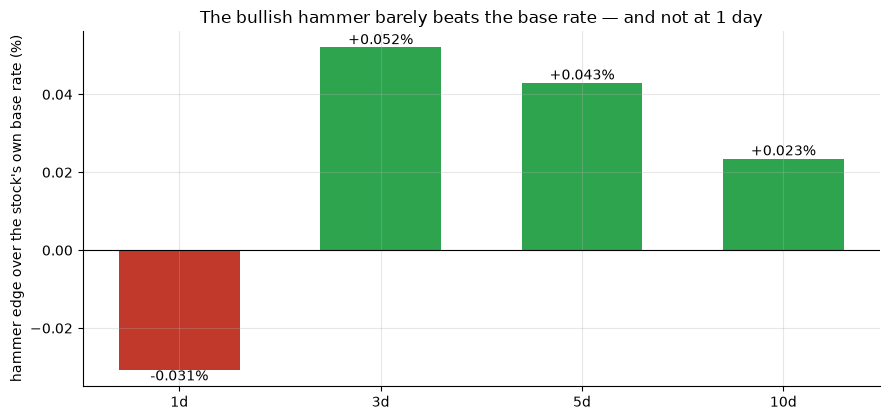

hammer edge by horizon (%): [-0.031, 0.052, 0.043, 0.023]


In [2]:
HS = [1, 3, 5, 10]
if HAVE_REAL:
    res = st.run_experiment(PANEL, side='hammer', n_draws=1500, seed=403)
    edge = [res[h]['edge_mean']*100 for h in HS]
else:
    edge = [R['hammer'][h][1] for h in HS]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols = [GREEN if v>0 else RED for v in edge]
ax.bar([f'{h}d' for h in HS], edge, color=cols, width=.6)
for i,v in enumerate(edge): ax.annotate(f'{v:+.3f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('hammer edge over the stock\'s own base rate (%)')
ax.set_title('The bullish hammer barely beats the base rate — and not at 1 day')
plt.tight_layout(); plt.show()
print('hammer edge by horizon (%):', [round(v,3) for v in edge])

That's the whole ballgame, and it's underwhelming. The best the hammer manages is **+0.052% at 3 days** — and at **1 day** it's actually *negative* (**-0.031%**). These are rounding-error sizes. (The quant notebook shows the matching *t* = 0.9 — i.e. indistinguishable from luck.)

**Now the hanging man** — the *same shape* after a rally. The folklore says it should call a **top** (negative forward returns). Let's put the two sides next to each other.

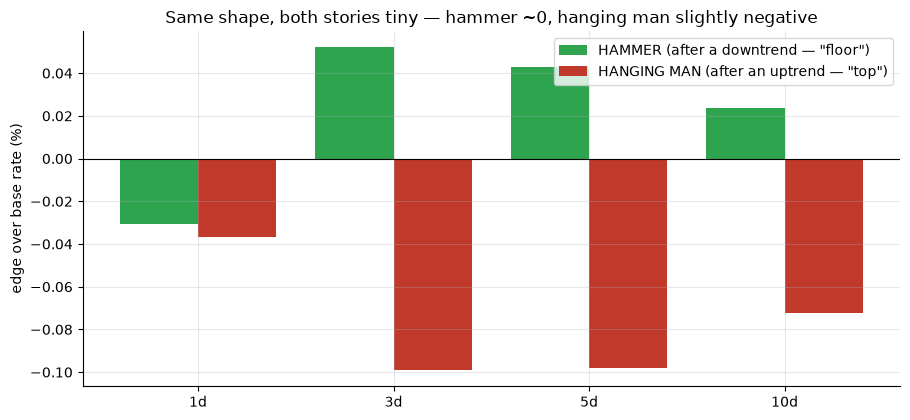

hammer: [-0.031, 0.052, 0.043, 0.023]  hanging man: [-0.037, -0.099, -0.098, -0.072]


In [3]:
if HAVE_REAL:
    rh = st.run_experiment(PANEL, side='hammer', placebo=False, n_draws=1, seed=403)
    rg = st.run_experiment(PANEL, side='hangingman', placebo=False, n_draws=1, seed=403)
    ham = [rh[h]['edge_mean']*100 for h in HS]; han = [rg[h]['edge_mean']*100 for h in HS]
else:
    ham = [R['hammer'][h][1] for h in HS]; han = [R['hang'][h][1] for h in HS]
x = np.arange(len(HS))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, ham, .4, color=GREEN, label='HAMMER (after a downtrend — "floor")')
ax.bar(x+.2, han, .4, color=RED, label='HANGING MAN (after an uptrend — "top")')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in HS])
ax.set_ylabel('edge over base rate (%)')
ax.set_title('Same shape, both stories tiny — hammer ~0, hanging man slightly negative')
ax.legend(); plt.tight_layout(); plt.show()
print('hammer:', [round(v,3) for v in ham], ' hanging man:', [round(v,3) for v in han])

The hanging man's bars *are* a bit negative (e.g. **-0.099% at 3 days**) — the only place anything statistically real shows up. But "negative edge" here means the stock rose **less than usual**, not that it fell. You can't short "a bit less up" and keep the lights on after costs. Neither side gives you a floor or a top you can actually trade.

**The give-away: the filter rescue.** Believers say "sure, but you need the *right* setup." So we tried. Watch what happens to the hammer's 3-day edge as we change the filters.

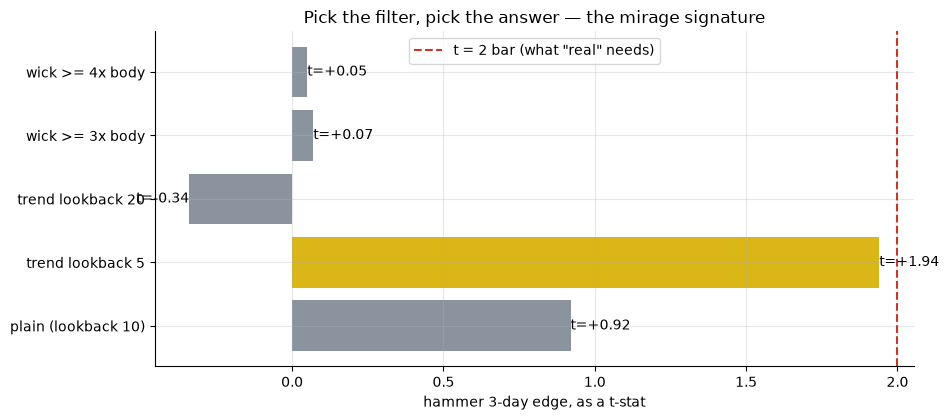

plain (lookback 10)      edge=+0.052%  t=+0.92
trend lookback 5         edge=+0.095%  t=+1.94
trend lookback 20        edge=-0.017%  t=-0.34
wick >= 3x body          edge=+0.005%  t=+0.07
wick >= 4x body          edge=+0.005%  t=+0.05


In [4]:
labels = [f[0] for f in R['filt']]; tvals = [f[2] for f in R['filt']]
fig, ax = plt.subplots(figsize=(9.6, 4.3))
cols = [AMBER if abs(t)>=1 else GREY for t in tvals]
ax.barh(range(len(labels)), tvals, color=cols)
ax.axvline(2, ls='--', c=RED, label='t = 2 bar (what "real" needs)')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i,t in enumerate(tvals): ax.annotate(f't={t:+.2f}',(t,i),va='center',ha='left' if t>=0 else 'right')
ax.set_xlabel('hammer 3-day edge, as a t-stat'); ax.set_title('Pick the filter, pick the answer — the mirage signature')
ax.legend(); plt.tight_layout(); plt.show()
for f in R['filt']: print(f'{f[0]:24s} edge={f[1]:+.3f}%  t={f[2]:+.2f}')

A **shorter** trend window (lookback 5) lifts *t* to **1.94** — almost there! — but a **longer** one (lookback 20) sends it back to zero, and demanding a *longer, purer* wick — the "textbook-perfect" hammer — **flattens it entirely** (*t* ≈ 0.05). When the answer swings with the knob you chose, you're not finding a signal. You're fishing.

## 5 · The verdict

- **Signal — None.** The bullish hammer never clears the bar: best **+0.05% at 3 days** (luck-level), negative at 1 day. The only real stat is the hanging man's faint *under*-performance — the wrong direction for a floor, and untradeable.
- **Tradability — Mirage.** After costs the edge is **negative everywhere, both sides.**
- **Reliable reversal? — Busted.** No floor, no shortable top, and the only "edge" comes from snooping the filter. A *bigger* wick makes it *worse*.

## 6 · Could you actually trade it? — costs finish it off

Even granting the tiny gross blip, here's the hammer **gross vs net** of a normal 5-bps round trip (buy at the next close, sell H days later).

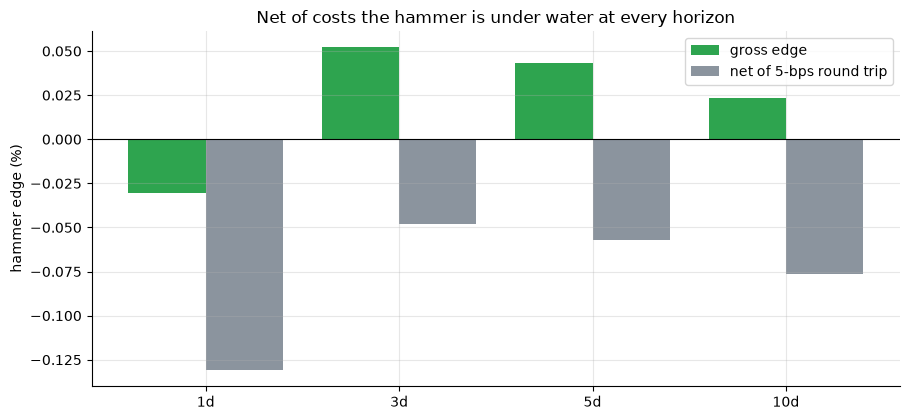

net hammer edge by horizon (%): [-0.131, -0.048, -0.057, -0.077]


In [5]:
if HAVE_REAL:
    rr = st.run_experiment(PANEL, side='hammer', placebo=False, n_draws=1, seed=403)
    g = [rr[h]['edge_mean']*100 for h in HS]; nv = [rr[h]['net_edge']*100 for h in HS]
else:
    g = [R['hammer'][h][1] for h in HS]; nv = [R['hammer'][h][4] for h in HS]
x = np.arange(len(HS))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=GREEN, label='gross edge')
ax.bar(x+.2, nv, .4, color=GREY, label='net of 5-bps round trip')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in HS])
ax.set_ylabel('hammer edge (%)'); ax.set_title('Net of costs the hammer is under water at every horizon')
ax.legend(); plt.tight_layout(); plt.show()
print('net hammer edge by horizon (%):', [round(v,3) for v in nv])

Every grey bar is below zero — net **-0.048%** even at the hammer's best (3-day) horizon. There was never a positive gross edge worth defending, and the round trip buries what little there was. Nothing to deploy.

## 7 · Going further 🚪

- **The wick is real, the forecast isn't.** A long lower shadow genuinely tells you buyers fought back *that day*. The lesson is that *intraday* information isn't a *multi-day* forecast — a trap that sinks most single-candle patterns.
- **Try small-caps / intraday.** Candle effects are bigger (and costlier) in illiquid names; re-run on a small-cap basket or on 5-minute bars and see if a thin edge appears.
- **Combine with a real signal.** A hammer *plus* an earnings surprise or a real reversal factor might do something the candle alone can't. Fork it and show the **net** edge clearing *t* = 2 — then we'll talk.

*The reproducible core is offline and deterministic. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*